# Per-Sample Network Visualization (Input vs Ground Truth)

Interactively browse individual samples from `train_33_69_84_nodes.csv`.
Each sample is shown as **two side-by-side networks**:

- **Left — Input**: the *starting* `Open Lines` from the `input` field (current tie-switch configuration before reconfiguration).
- **Right — Output / Ground Truth**: the *optimized* `Open Lines` from the `output` field (what the optimizer chose).

**Controls per network size:**
- `Split:` — switch between `train` / `validation` / `test`
- `← Prev` / `Next →` — step through samples
- `Sample idx:` — jump to a specific sample

**Edges:**
- **Solid blue** — line is closed in this sample
- **Dashed red** — line is open (in `Open Lines`)

In [1]:
import csv
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import ipywidgets as widgets
from IPython.display import display

csv.field_size_limit(2**30)

CSV_PATH = Path('Processed/train_33_69_84_nodes.csv')
if not CSV_PATH.exists():
    CSV_PATH = Path('../Dataset/Processed/train_33_69_84_nodes.csv')
print('Using:', CSV_PATH.resolve())

Using: /Users/town/Codes/RL4DistReconfig/Dataset/Processed/train_33_69_84_nodes.csv


In [2]:
BUSSES_RE  = re.compile(r'Busses\s*=\s*(\d+)')
LINES_RE   = re.compile(r'Lines\s*=\s*\[([^\]]*)\]')
OPENL_RE   = re.compile(r'Open Lines\s*=\s*\[([^\]]*)\]')
SYSLOSS_RE = re.compile(r'System Loss\s*=\s*([\d.eE+-]+)')
TUPLE_RE   = re.compile(r'\(\s*(\d+)\s*,\s*(\d+)\s*\)')

def parse_edges(s):
    return [tuple(sorted((int(a), int(b)))) for a, b in TUPLE_RE.findall(s)]

def maybe_float(m):
    return float(m.group(1)) if m else None

# Load CSV once; group samples by (split, size).
# Each sample dict captures both input (starting) and output (ground truth) configs.
samples = defaultdict(list)        # (split, size) -> [sample dict, ...]
topology_by_size = {}              # size -> set of all edges (canonical)

with open(CSV_PATH, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        bm = BUSSES_RE.search(row['input'])
        lm = LINES_RE.search(row['input'])
        in_om  = OPENL_RE.search(row['input'])
        out_om = OPENL_RE.search(row['output'])
        if not (bm and lm and in_om and out_om):
            continue
        n = int(bm.group(1))
        if n not in topology_by_size:
            topology_by_size[n] = set(parse_edges(lm.group(1)))
        samples[(row['split'], n)].append({
            'id': row['id'],
            'input_open_lines':  set(parse_edges(in_om.group(1))),
            'output_open_lines': set(parse_edges(out_om.group(1))),
            'input_system_loss':  maybe_float(SYSLOSS_RE.search(row['input'])),
            'output_system_loss': maybe_float(SYSLOSS_RE.search(row['output'])),
        })

print('Sample counts:')
for (split, n) in sorted(samples):
    print(f'  {split:>10} | {n}-node : {len(samples[(split, n)]):>6,}')

Sample counts:
        test | 33-node :  5,840
        test | 69-node :  5,840
        test | 84-node :  5,840
       train | 33-node :  5,840
       train | 69-node :  5,840
       train | 84-node :  5,840
  validation | 33-node :  5,840
  validation | 69-node :  5,840
  validation | 84-node :  5,840


In [3]:
# Precompute one stable layout per network size so node positions don't
# jump around as we flip through samples.
layouts = {}
for n, edges in topology_by_size.items():
    G = nx.Graph()
    G.add_nodes_from(range(1, n + 1))
    G.add_edges_from(edges)
    layouts[n] = nx.kamada_kawai_layout(G)
print('Layouts precomputed for sizes:', sorted(layouts))

Layouts precomputed for sizes: [33, 69, 84]


In [4]:
def _draw_one(ax, size, open_set, title):
    ax.clear()
    all_edges = topology_by_size[size]
    closed_edges = [e for e in all_edges if e not in open_set]
    open_edges   = [e for e in all_edges if e in open_set]

    G = nx.Graph()
    G.add_nodes_from(range(1, size + 1))
    G.add_edges_from(all_edges)
    pos = layouts[size]

    nx.draw_networkx_edges(G, pos, edgelist=closed_edges, ax=ax,
                           edge_color='#1f77b4', width=1.3, alpha=0.85)
    nx.draw_networkx_edges(G, pos, edgelist=open_edges, ax=ax,
                           edge_color='#d62728', width=2.0, style='dashed', alpha=0.95)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#fbe9b1',
                           edgecolors='#333', linewidths=0.6,
                           node_size=max(80, 1500 // size))
    if size <= 90:
        nx.draw_networkx_labels(G, pos, ax=ax,
                                font_size=max(5, 9 - size // 25))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def plot_sample(axes, size, sample):
    """Draw input (left) and output/ground-truth (right) for one sample."""
    ax_in, ax_out = axes
    in_open  = sample['input_open_lines']
    out_open = sample['output_open_lines']

    in_str  = ', '.join(f'({a},{b})' for a, b in sorted(in_open))
    out_str = ', '.join(f'({a},{b})' for a, b in sorted(out_open))
    in_loss  = f'{sample["input_system_loss"]:.4f}'  if sample['input_system_loss']  is not None else 'N/A'
    out_loss = f'{sample["output_system_loss"]:.4f}' if sample['output_system_loss'] is not None else 'N/A'

    _draw_one(ax_in,  size, in_open,
              f'INPUT (starting config) — id={sample["id"]}\n'
              f'System Loss = {in_loss}\n'
              f'Open Lines = [{in_str}]')
    _draw_one(ax_out, size, out_open,
              f'OUTPUT (ground truth) — id={sample["id"]}\n'
              f'System Loss = {out_loss}\n'
              f'Open Lines = [{out_str}]')

    # Highlight edges that changed between input and output (in title row).
    only_in  = sorted(in_open  - out_open)
    only_out = sorted(out_open - in_open)
    diff_msg = (f'Δ open lines  — closed in output: {only_in or "(none)"}'
                f'   |   newly opened in output: {only_out or "(none)"}')
    ax_out.figure.suptitle(diff_msg, fontsize=10, y=1.02)

## 33-node network

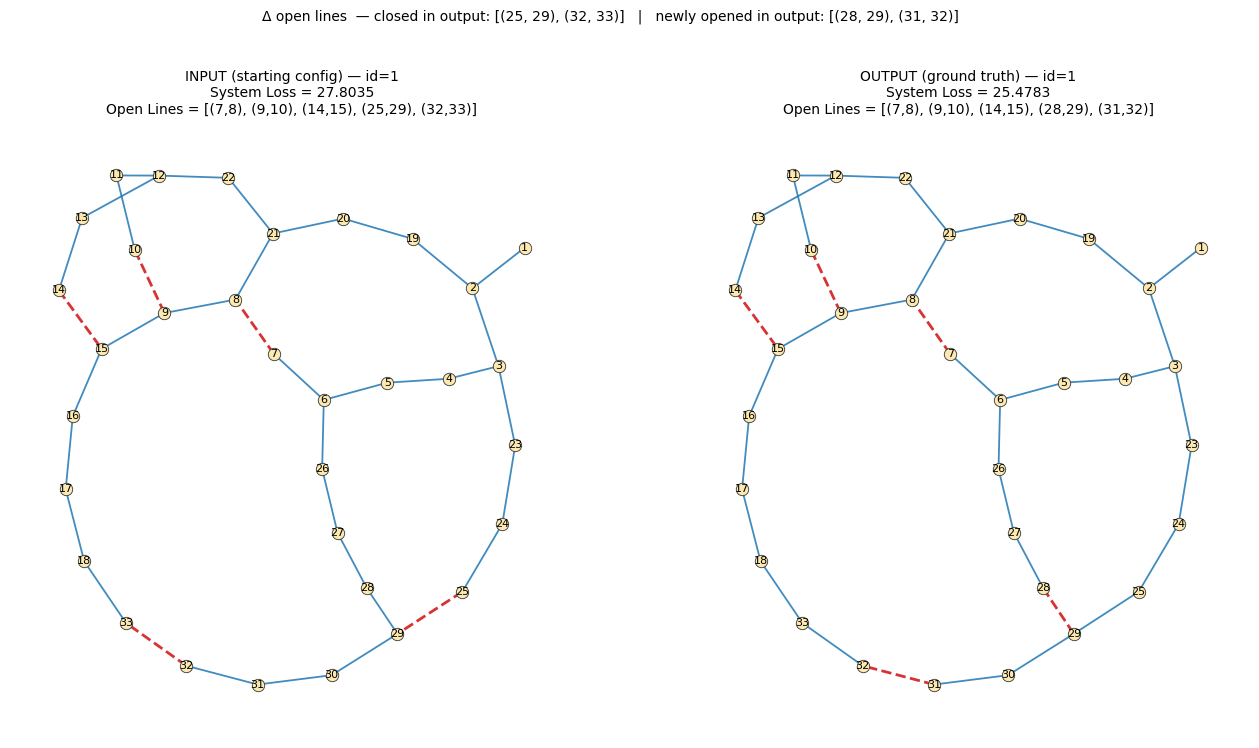

In [5]:
def make_browser(size):
    """Build an independent split/idx browser for a given network size."""
    split_dd = widgets.Dropdown(
        options=['train', 'validation', 'test'], value='train',
        description='Split:', layout=widgets.Layout(width='200px'))
    prev_btn = widgets.Button(description='← Prev', layout=widgets.Layout(width='80px'))
    next_btn = widgets.Button(description='Next →', layout=widgets.Layout(width='80px'))
    idx_slider = widgets.IntSlider(value=0, min=0, max=0, step=1,
                                   description='Sample idx:',
                                   layout=widgets.Layout(width='480px'),
                                   continuous_update=False)
    info_label = widgets.Label(value='')
    out = widgets.Output()

    state = {'fig': None, 'axes': None}

    def current_list():
        return samples.get((split_dd.value, size), [])

    def render():
        lst = current_list()
        if not lst:
            info_label.value = f'(no samples for split={split_dd.value})'
            with out:
                out.clear_output(wait=True)
            return
        idx = idx_slider.value
        idx = max(0, min(idx, len(lst) - 1))
        idx_slider.value = idx
        sample = lst[idx]
        info_label.value = f'sample {idx + 1} / {len(lst):,}'
        with out:
            out.clear_output(wait=True)
            if state['fig'] is None:
                state['fig'], state['axes'] = plt.subplots(1, 2, figsize=(16, 8))
            plot_sample(state['axes'], size, sample)
            display(state['fig'])

    def on_split_change(_change):
        lst = current_list()
        idx_slider.max = max(0, len(lst) - 1)
        idx_slider.value = 0
        render()

    def on_idx_change(_change):
        render()

    def on_prev(_b):
        if idx_slider.value > 0:
            idx_slider.value -= 1

    def on_next(_b):
        if idx_slider.value < idx_slider.max:
            idx_slider.value += 1

    split_dd.observe(on_split_change, names='value')
    idx_slider.observe(on_idx_change, names='value')
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

    # initialise slider range
    lst = current_list()
    idx_slider.max = max(0, len(lst) - 1)

    controls = widgets.HBox([split_dd, prev_btn, next_btn, idx_slider, info_label])
    ui = widgets.VBox([controls, out])
    display(ui)
    render()

make_browser(33)

## 69-node network

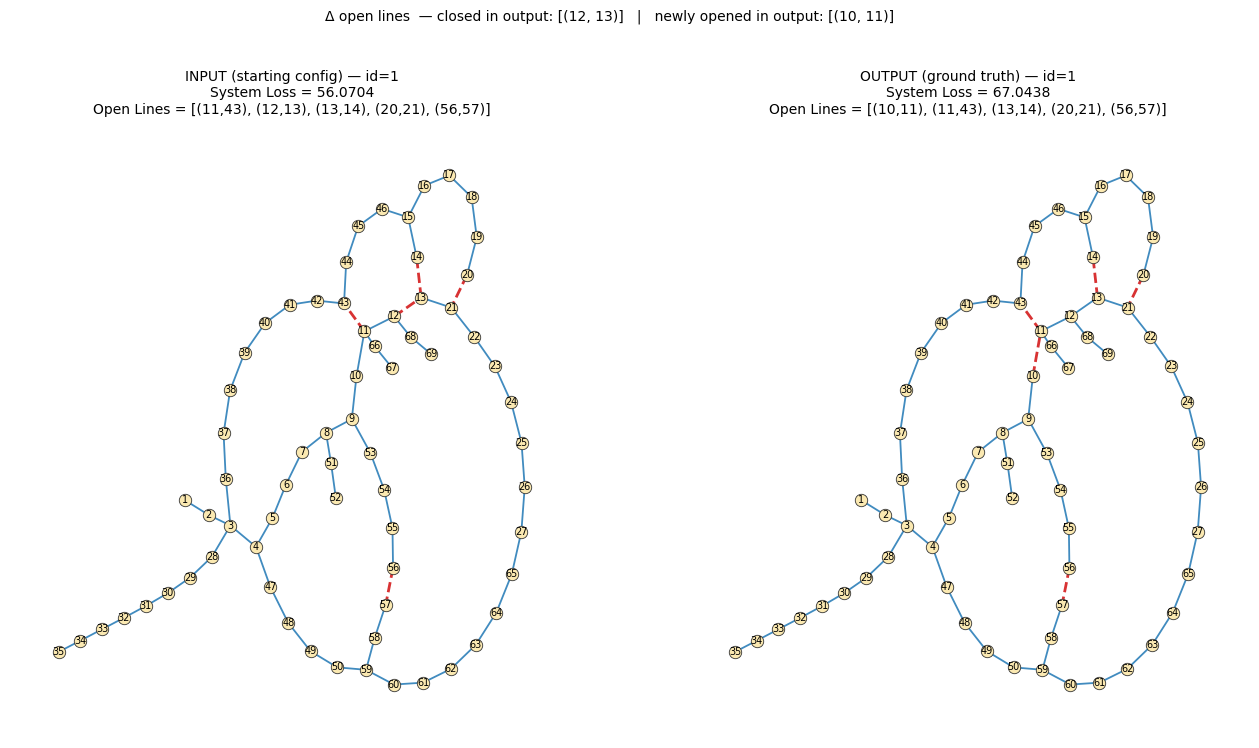

In [6]:
make_browser(69)

## 84-node network

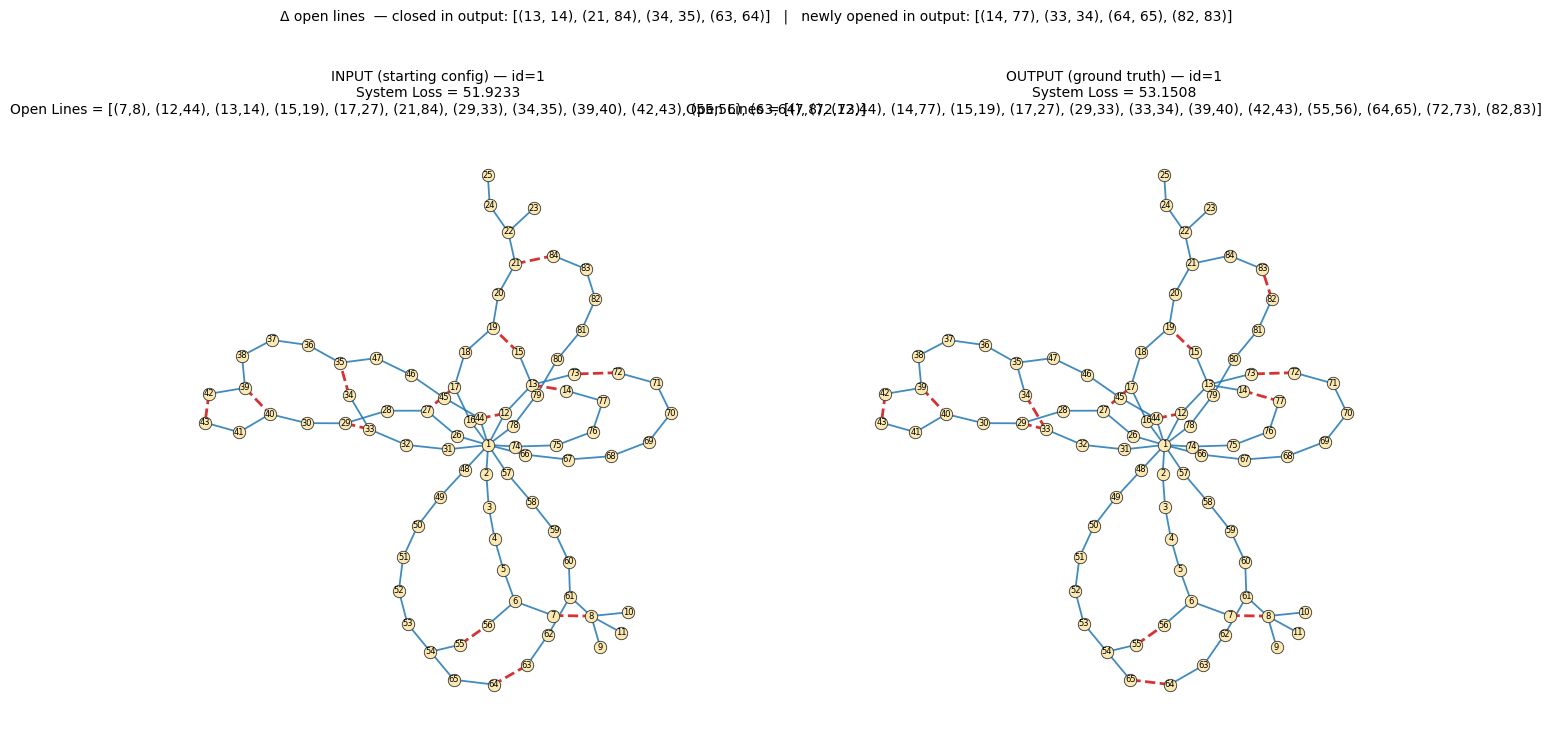

In [7]:
make_browser(84)